In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose, STL
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_squared_error, r2_score

import scipy.stats as stats
from scipy.fft import fft, fftfreq

import pywt

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.grid"] = True
sns.set_style("whitegrid")

In [2]:
df = pd.read_csv("retail_sales_mock_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

df = df.sort_values("Date").reset_index(drop=True)

df = df.set_index("Date")

display(df.head())

print("Размер таблицы:", df.shape)
print("\nТипы данных:")
print(df.dtypes)

,SalesAmount,Promotion,HolidayMonth
Date,,,
2020-01-01,12248,0,0
2020-02-01,13011,0,0
2020-03-01,12722,0,0
2020-04-01,14030,1,0
2020-05-01,7783,0,0


Размер таблицы: (48, 3)

Типы данных:
SalesAmount     int64
Promotion       int64
HolidayMonth    int64
dtype: object


In [3]:
print("Пропуски:")
print(df.isna().sum())

print("\nДубликаты:", df.duplicated().sum())

print("\nОписательная статистика:")
display(df.describe())

Пропуски:
SalesAmount     0
Promotion       0
HolidayMonth    0
dtype: int64

Дубликаты: 0

Описательная статистика:


,SalesAmount,Promotion,HolidayMonth
count,48.000000,48.000000,48.000000
mean,11768.541667,0.125000,0.083333
std,2257.544863,0.334219,0.279310
min,7783.000000,0.000000,0.000000
25%,10219.750000,0.000000,0.000000
50%,11851.000000,0.000000,0.000000
75%,13014.000000,0.000000,0.000000
max,17996.000000,1.000000,1.000000



Промежуточный вывод:
1. Данные успешно загружены и приведены к формату временного ряда.
2. Поле Date используется как индекс, что удобно для анализа и моделирования.
3. Проверены пропуски, дубликаты и базовые статистики.
4. Далее можно переходить к визуальному разведочному анализу (EDA).


In [5]:
!pip install PyWavelets

## 2. Разведочный анализ данных (EDA)

На этом этапе выполняется первичный визуальный и статистический анализ временного ряда:

- график продаж во времени;
- сглаживание с помощью скользящего среднего;
- анализ сезонности по месяцам;
- сравнение продаж по годам;
- проверка стационарности ряда;
- построение ACF и PACF для предварительной оценки структуры зависимости.

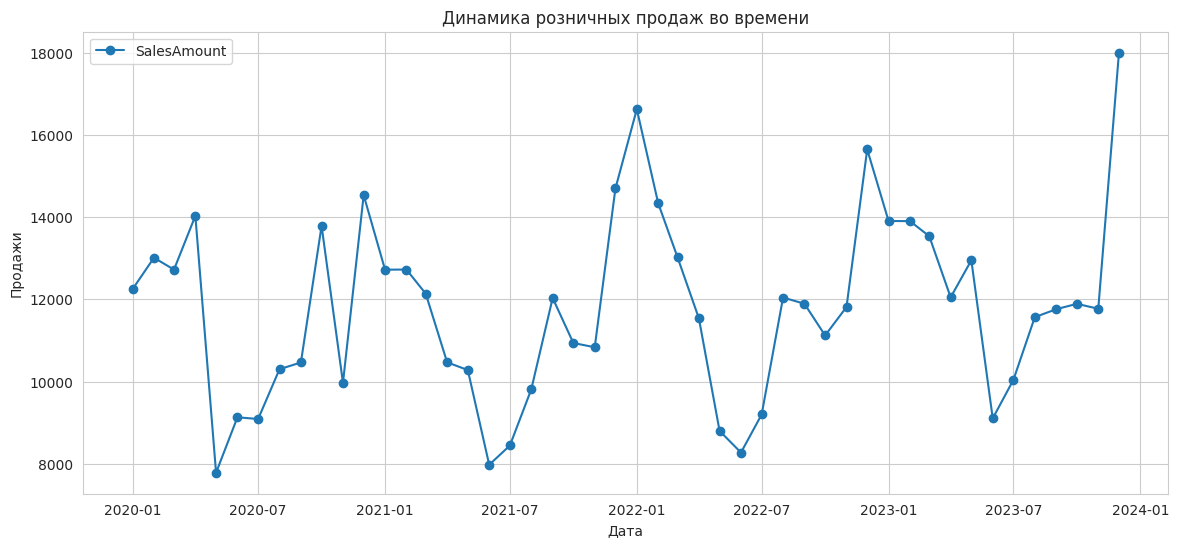

In [6]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["SalesAmount"], marker="o", label="SalesAmount")
ax.set_title("Динамика розничных продаж во времени")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

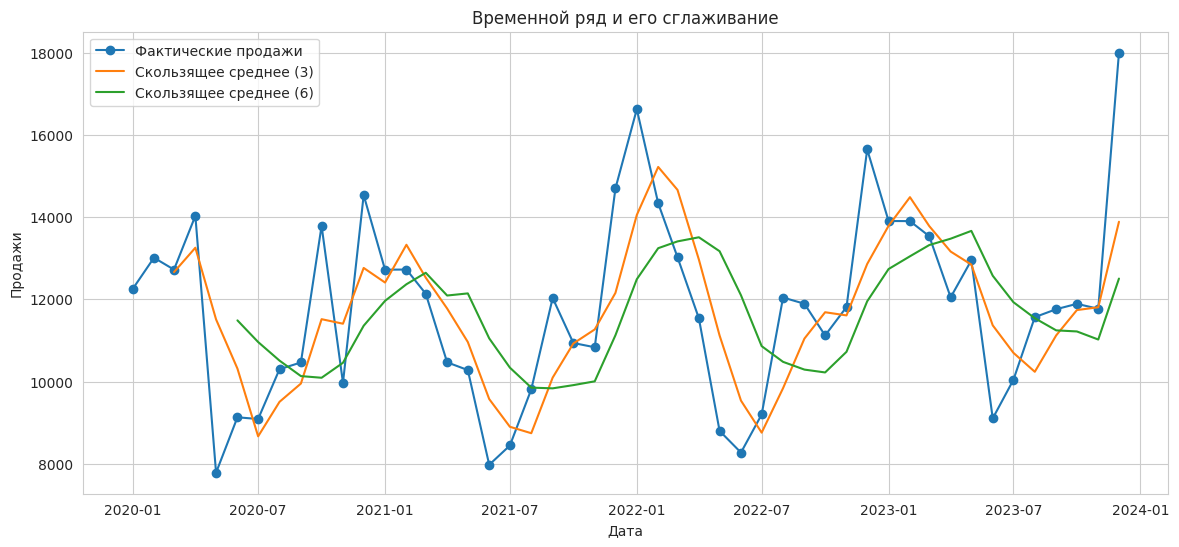

In [7]:
df["RollingMean_3"] = df["SalesAmount"].rolling(window=3).mean()
df["RollingMean_6"] = df["SalesAmount"].rolling(window=6).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df.index, df["SalesAmount"], marker="o", label="Фактические продажи")
ax.plot(df.index, df["RollingMean_3"], label="Скользящее среднее (3)")
ax.plot(df.index, df["RollingMean_6"], label="Скользящее среднее (6)")
ax.set_title("Временной ряд и его сглаживание")
ax.set_xlabel("Дата")
ax.set_ylabel("Продажи")
ax.legend()
plt.show()

In [8]:
df_eda = df.copy()

df_eda["Year"] = df_eda.index.year
df_eda["Month"] = df_eda.index.month

month_map = {
    1: "Jan", 2: "Feb", 3: "Mar", 4: "Apr",
    5: "May", 6: "Jun", 7: "Jul", 8: "Aug",
    9: "Sep", 10: "Oct", 11: "Nov", 12: "Dec"
}

df_eda["MonthName"] = df_eda["Month"].map(month_map)

month_order = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
               "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

display(df_eda.head())

,SalesAmount,Promotion,HolidayMonth,RollingMean_3,RollingMean_6,Year,Month,MonthName
Date,,,,,,,,
2020-01-01,12248,0,0,NaN,NaN,2020,1,Jan
2020-02-01,13011,0,0,NaN,NaN,2020,2,Feb
2020-03-01,12722,0,0,12660.333333,NaN,2020,3,Mar
2020-04-01,14030,1,0,13254.333333,NaN,2020,4,Apr
2020-05-01,7783,0,0,11511.666667,NaN,2020,5,May


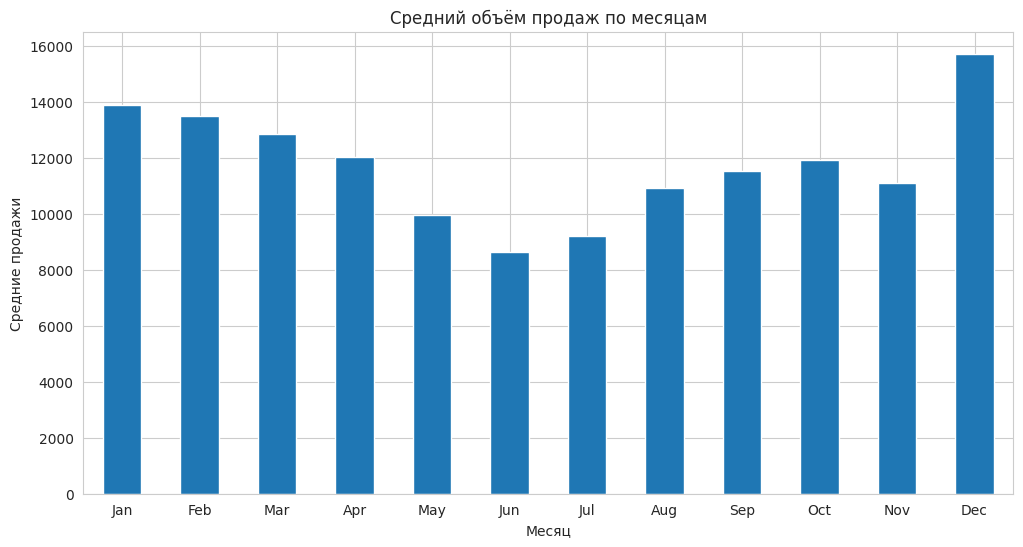

,AverageSales
MonthName,
Jan,13873.75
Feb,13493.00
Mar,12853.75
Apr,12020.75
May,9952.75
Jun,8621.00
Jul,9193.75
Aug,10929.75
Sep,11536.50


In [9]:
monthly_avg = (
    df_eda.groupby("MonthName")["SalesAmount"]
    .mean()
    .reindex(month_order)
)

fig, ax = plt.subplots(figsize=(12, 6))
monthly_avg.plot(kind="bar", ax=ax)
ax.set_title("Средний объём продаж по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Средние продажи")
plt.xticks(rotation=0)
plt.show()

display(monthly_avg.to_frame(name="AverageSales"))

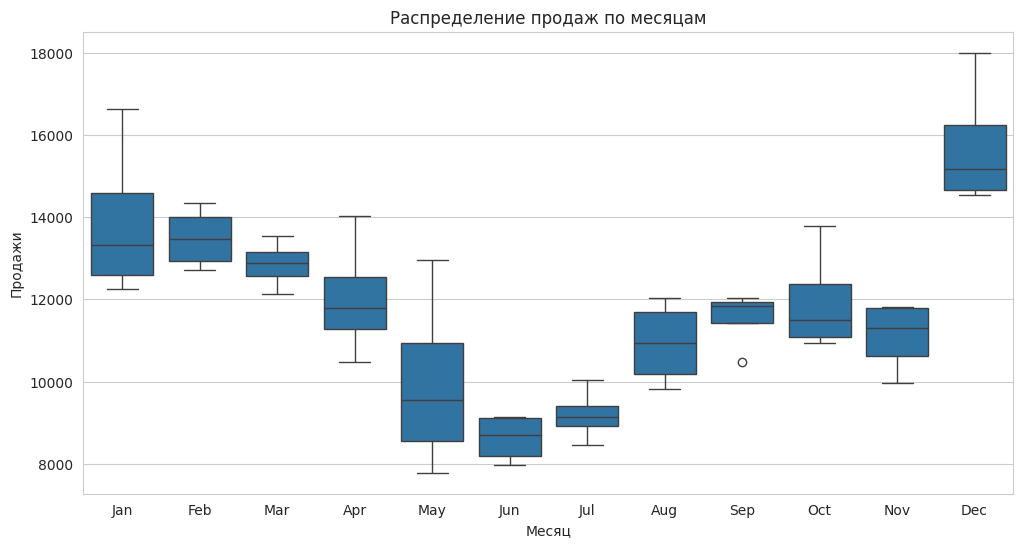

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=df_eda, x="MonthName", y="SalesAmount", order=month_order, ax=ax)
ax.set_title("Распределение продаж по месяцам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Продажи")
plt.show()

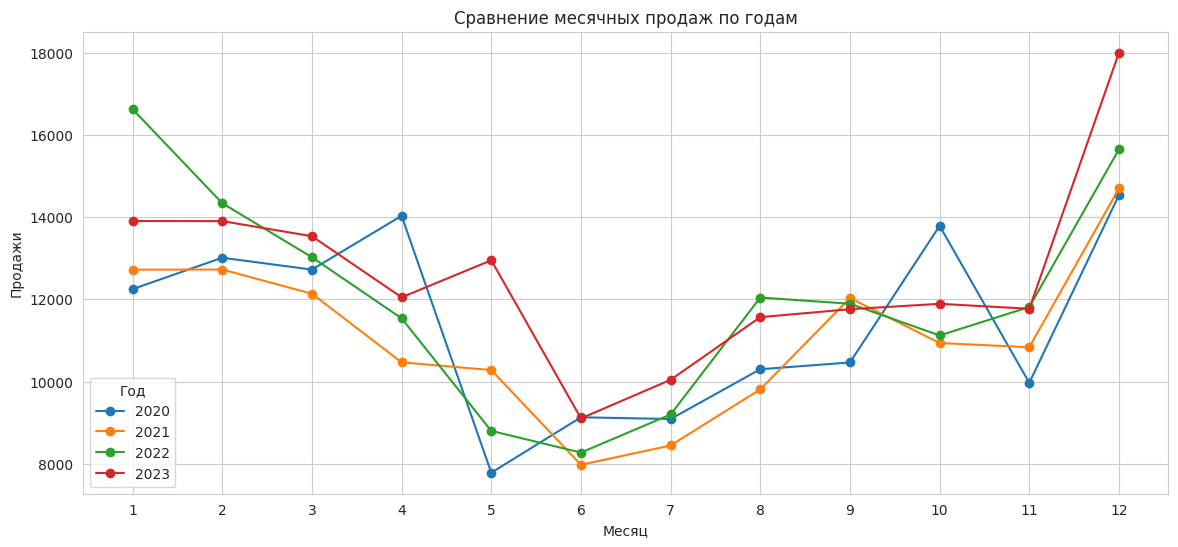

In [11]:
fig, ax = plt.subplots(figsize=(14, 6))

for year in sorted(df_eda["Year"].unique()):
    temp = df_eda[df_eda["Year"] == year]
    ax.plot(temp["Month"], temp["SalesAmount"], marker="o", label=str(year))

ax.set_title("Сравнение месячных продаж по годам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Продажи")
ax.set_xticks(range(1, 13))
ax.legend(title="Год")
plt.show()

In [12]:
promo_stats = df.groupby("Promotion")["SalesAmount"].agg(["count", "mean", "median", "std"])
holiday_stats = df.groupby("HolidayMonth")["SalesAmount"].agg(["count", "mean", "median", "std"])

print("Статистика продаж по признаку Promotion:")
display(promo_stats)

print("Статистика продаж по признаку HolidayMonth:")
display(holiday_stats)

Статистика продаж по признаку Promotion:


,count,mean,median,std
Promotion,,,,
0,42,11621.238095,11791.0,2182.556364
1,6,12799.666667,13367.5,2718.073852


Статистика продаж по признаку HolidayMonth:


,count,mean,median,std
HolidayMonth,,,,
0,44,11409.522727,11764.5,1951.973438
1,4,15717.750000,15170.5,1595.927395


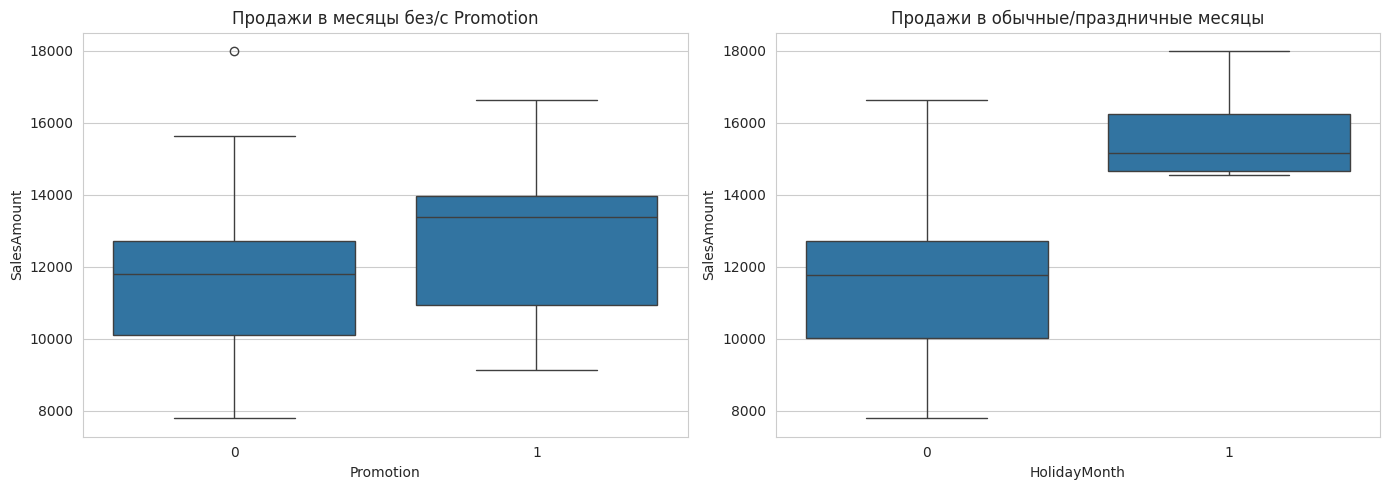

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df.reset_index(), x="Promotion", y="SalesAmount", ax=axes[0])
axes[0].set_title("Продажи в месяцы без/с Promotion")
axes[0].set_xlabel("Promotion")
axes[0].set_ylabel("SalesAmount")

sns.boxplot(data=df.reset_index(), x="HolidayMonth", y="SalesAmount", ax=axes[1])
axes[1].set_title("Продажи в обычные/праздничные месяцы")
axes[1].set_xlabel("HolidayMonth")
axes[1].set_ylabel("SalesAmount")

plt.tight_layout()
plt.show()

In [14]:
def adf_test(series, title=""):
    result = adfuller(series.dropna())
    labels = [
        "ADF Statistic",
        "p-value",
        "Lags Used",
        "Number of Observations Used"
    ]

    print(f"ADF-тест для: {title}")
    for value, label in zip(result[:4], labels):
        print(f"{label}: {value}")

    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value}")

    if result[1] <= 0.05:
        print("\nВывод: ряд стационарен (отвергаем H0).")
    else:
        print("\nВывод: ряд нестационарен (не отвергаем H0).")

adf_test(df["SalesAmount"], "SalesAmount")

ADF-тест для: SalesAmount
ADF Statistic: -4.5141835977339575
p-value: 0.00018535586430261453
Lags Used: 5
Number of Observations Used: 42
Critical Values:
   1%: -3.596635636000432
   5%: -2.933297331821618
   10%: -2.6049909750566895

Вывод: ряд стационарен (отвергаем H0).


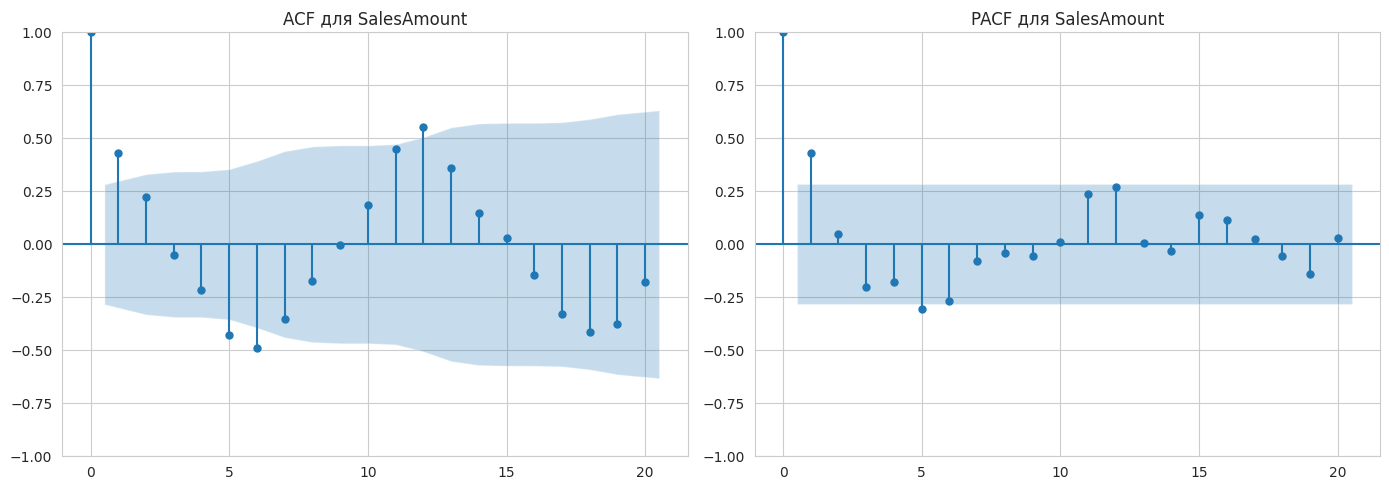

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_acf(df["SalesAmount"].dropna(), lags=20, ax=axes[0])
axes[0].set_title("ACF для SalesAmount")

plot_pacf(df["SalesAmount"].dropna(), lags=20, ax=axes[1], method="ywm")
axes[1].set_title("PACF для SalesAmount")

plt.tight_layout()
plt.show()

Аналитический вывод по этапу EDA:

1. Временной ряд продаж демонстрирует выраженные колебания во времени.
2. По графикам и агрегации по месяцам можно ожидать наличие сезонности, вероятно с периодом 12 месяцев.
3. Сравнение по годам позволяет увидеть повторяющийся сезонный профиль, что важно для выбора сезонной модели.
4. Признаки Promotion и HolidayMonth потенциально влияют на продажи, поэтому могут быть полезны как экзогенные переменные в модели SARIMAX.
5. ADF-тест и графики ACF/PACF помогают оценить стационарность и предварительно понять структуру временной зависимости.
6. Полученные результаты будут использоваться на следующем этапе для декомпозиции ряда и подбора параметров ARIMA/SARIMAX.


## 3. Декомпозиция временного ряда

На этом этапе временной ряд раскладывается на основные компоненты разными методами:

1. Классическая аддитивная декомпозиция  
2. Классическая мультипликативная декомпозиция  
3. STL-декомпозиция  
4. Спектральный анализ с помощью FFT  
5. Вейвлет-анализ

Цель этапа — выявить тренд, сезонность и особенности колебаний ряда, а также сравнить применимость разных подходов к анализу розничных продаж.

In [16]:
ts = df["SalesAmount"].copy()

print("Количество наблюдений:", len(ts))
print("Минимум:", ts.min())
print("Максимум:", ts.max())
print("Все значения положительные:", (ts > 0).all())

Количество наблюдений: 48
Минимум: 7783
Максимум: 17996
Все значения положительные: True


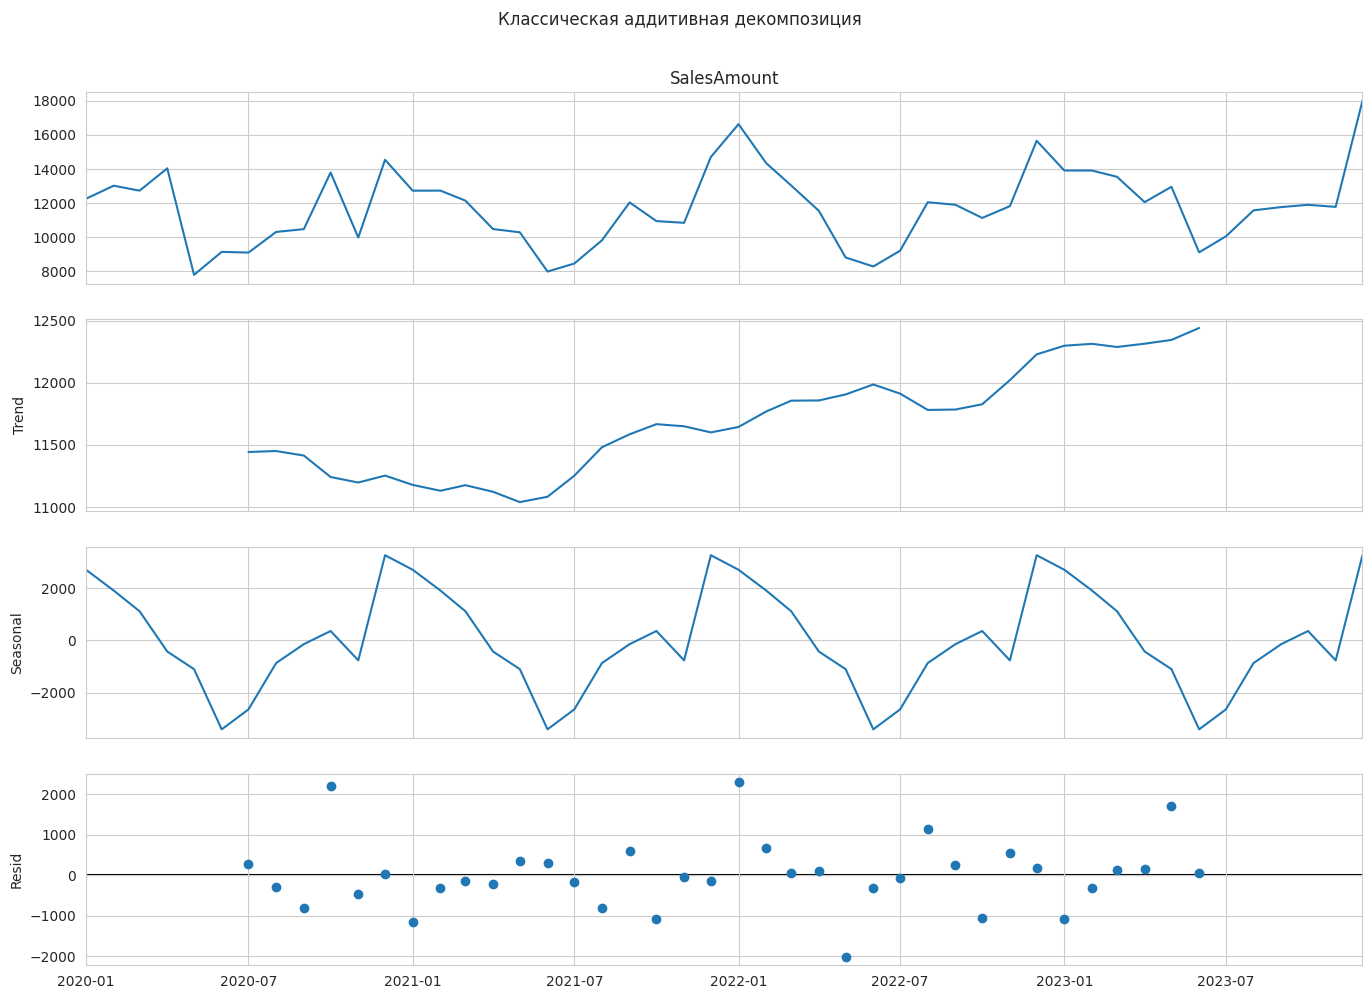

In [17]:
decompose_add = seasonal_decompose(ts, model="additive", period=12)

fig = decompose_add.plot()
fig.set_size_inches(14, 10)
fig.suptitle("Классическая аддитивная декомпозиция", y=1.02)
plt.show()

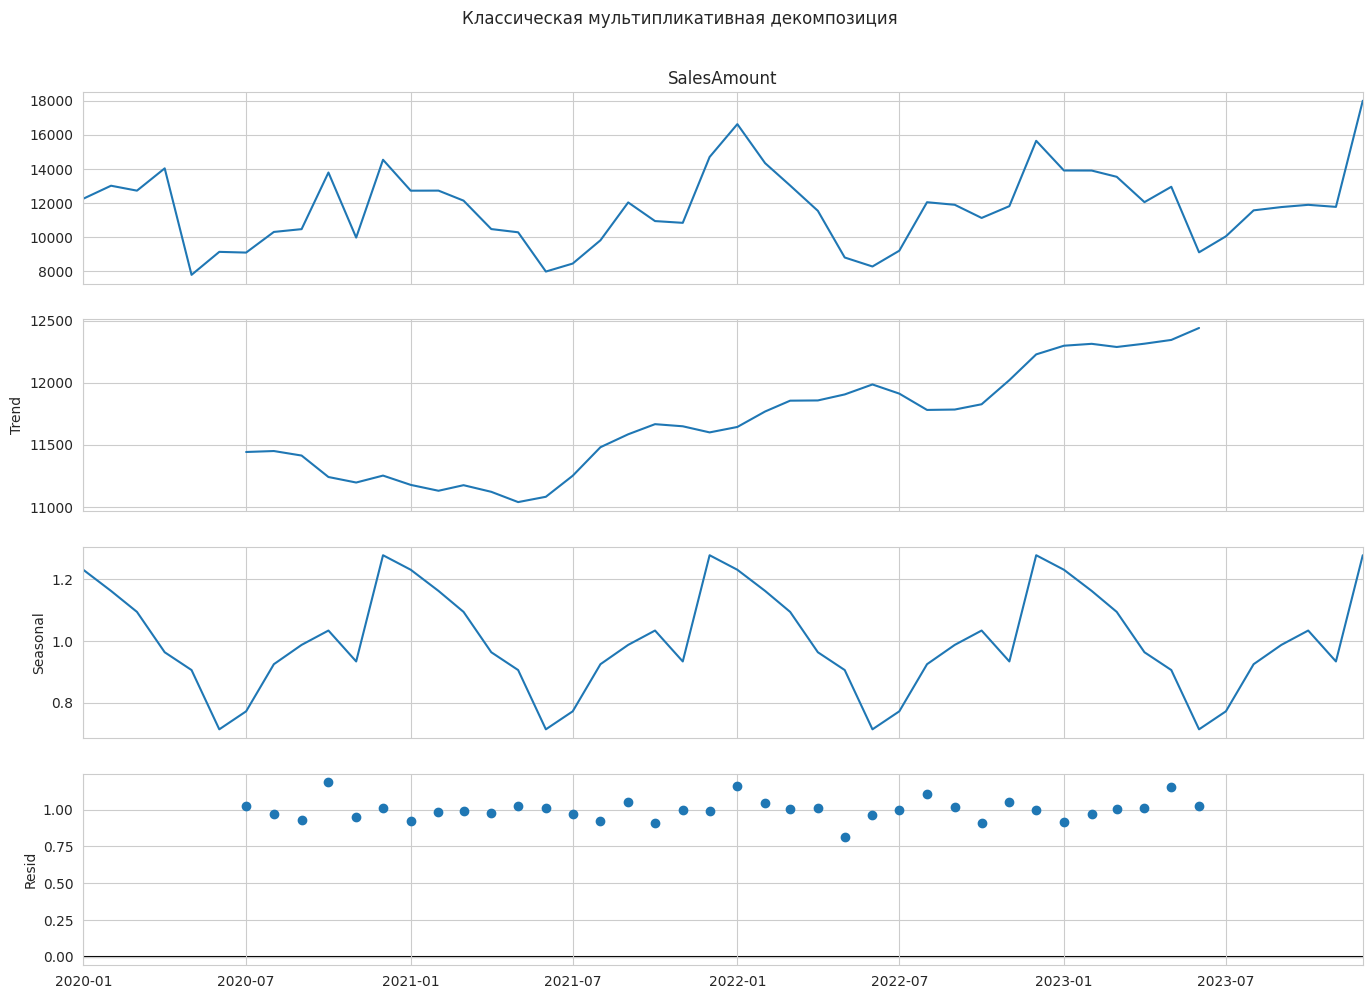

In [18]:
if (ts > 0).all():
    decompose_mul = seasonal_decompose(ts, model="multiplicative", period=12)

    fig = decompose_mul.plot()
    fig.set_size_inches(14, 10)
    fig.suptitle("Классическая мультипликативная декомпозиция", y=1.02)
    plt.show()
else:
    print("Мультипликативная декомпозиция невозможна: в ряду есть нулевые или отрицательные значения.")

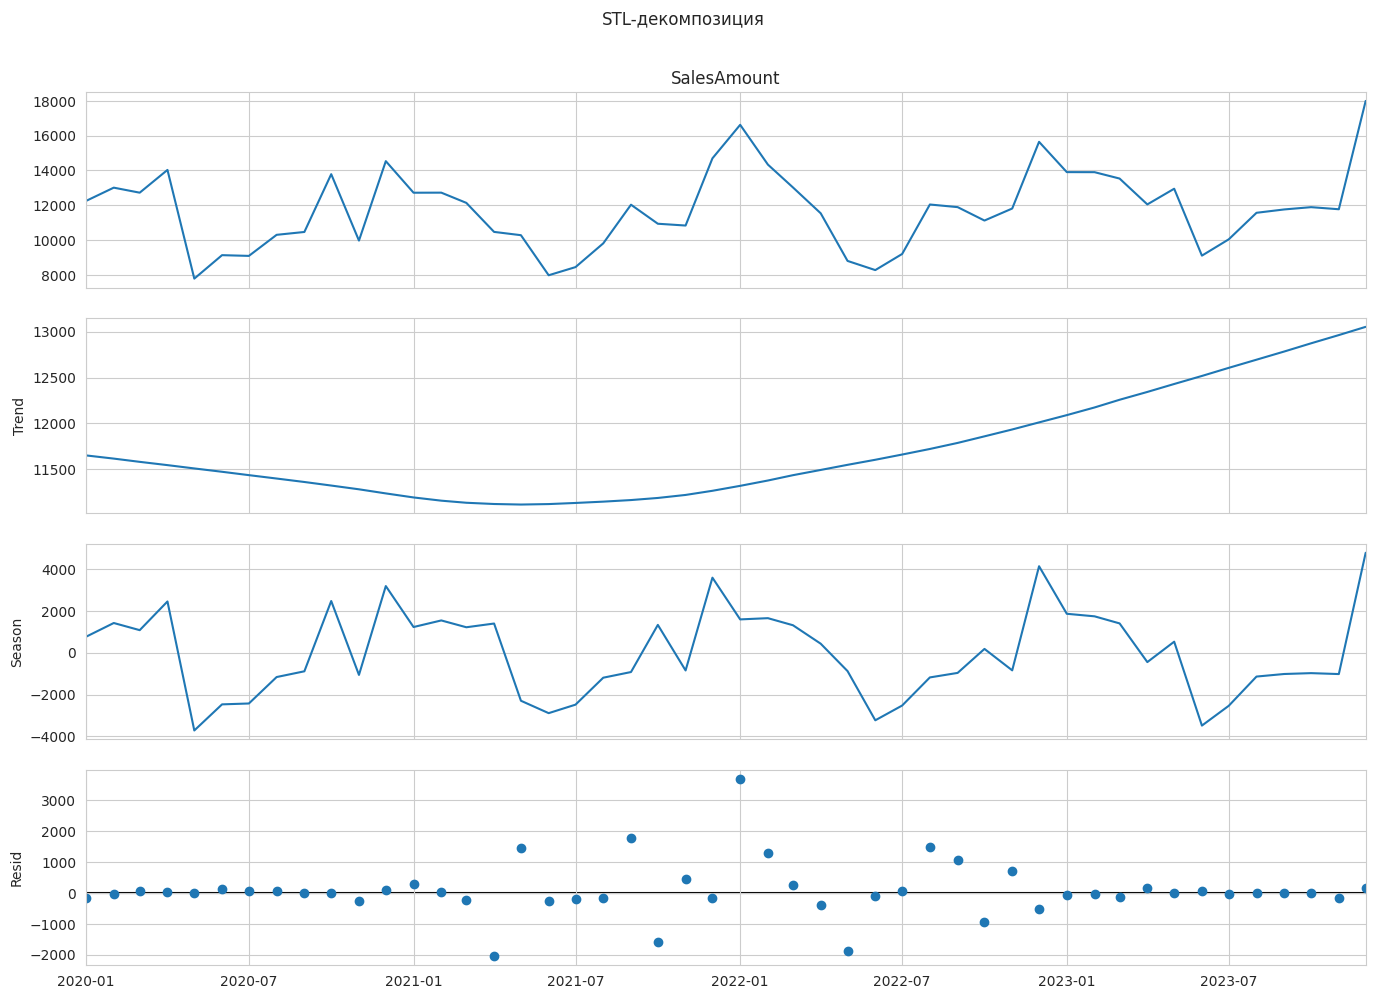

In [19]:
stl = STL(ts, period=12, robust=True)
stl_result = stl.fit()

fig = stl_result.plot()
fig.set_size_inches(14, 10)
fig.suptitle("STL-декомпозиция", y=1.02)
plt.show()

In [20]:
comparison_df = pd.DataFrame(index=ts.index)
comparison_df["Original"] = ts
comparison_df["Add_Trend"] = decompose_add.trend
comparison_df["Add_Seasonal"] = decompose_add.seasonal
comparison_df["STL_Trend"] = stl_result.trend
comparison_df["STL_Seasonal"] = stl_result.seasonal
comparison_df["STL_Resid"] = stl_result.resid

if (ts > 0).all():
    comparison_df["Mul_Trend"] = decompose_mul.trend
    comparison_df["Mul_Seasonal"] = decompose_mul.seasonal

display(comparison_df.head(15))

,Original,Add_Trend,Add_Seasonal,STL_Trend,STL_Seasonal,STL_Resid,Mul_Trend,Mul_Seasonal
Date,,,,,,,,
2020-01-01,12248,NaN,2697.581019,11652.613382,766.188269,-170.801651,NaN,1.231079
2020-02-01,13011,NaN,1904.761574,11617.873421,1423.803562,-30.676983,NaN,1.162505
2020-03-01,12722,NaN,1113.192130,11582.602547,1081.564050,57.833403,NaN,1.094408
2020-04-01,14030,NaN,-425.127315,11546.901947,2453.560198,29.537855,NaN,0.963414
2020-05-01,7783,NaN,-1098.807870,11510.851614,-3715.122344,-12.729270,NaN,0.905684
2020-06-01,9131,NaN,-3396.905093,11474.508201,-2466.782234,123.274033,NaN,0.713337
2020-07-01,9089,11441.916667,-2635.877315,11437.899718,-2424.938591,76.038872,11441.916667,0.771763
2020-08-01,10300,11449.625000,-864.571759,11400.945215,-1160.366907,59.421691,11449.625000,0.924679
2020-09-01,10464,11413.250000,-143.543981,11363.386867,-885.749002,-13.637865,11413.250000,0.987356


In [21]:
n = len(ts)
y = ts.values

fft_values = fft(y)
freqs = fftfreq(n, d=1)

positive_mask = freqs > 0
positive_freqs = freqs[positive_mask]
positive_amplitudes = np.abs(fft_values[positive_mask])

fft_df = pd.DataFrame({
    "frequency": positive_freqs,
    "amplitude": positive_amplitudes
})

fft_df["period_months"] = 1 / fft_df["frequency"]

fft_top = fft_df.sort_values("amplitude", ascending=False).reset_index(drop=True)

display(fft_top.head(10))

,frequency,amplitude,period_months
0,0.083333,57678.596627,12.000000
1,0.250000,20504.204886,4.000000
2,0.020833,14794.639886,48.000000
3,0.416667,13539.812449,2.400000
4,0.479167,13082.050407,2.086957
5,0.458333,12407.895132,2.181818
6,0.166667,12263.056593,6.000000
7,0.270833,12236.138491,3.692308
8,0.291667,11466.966007,3.428571
9,0.187500,11426.921760,5.333333


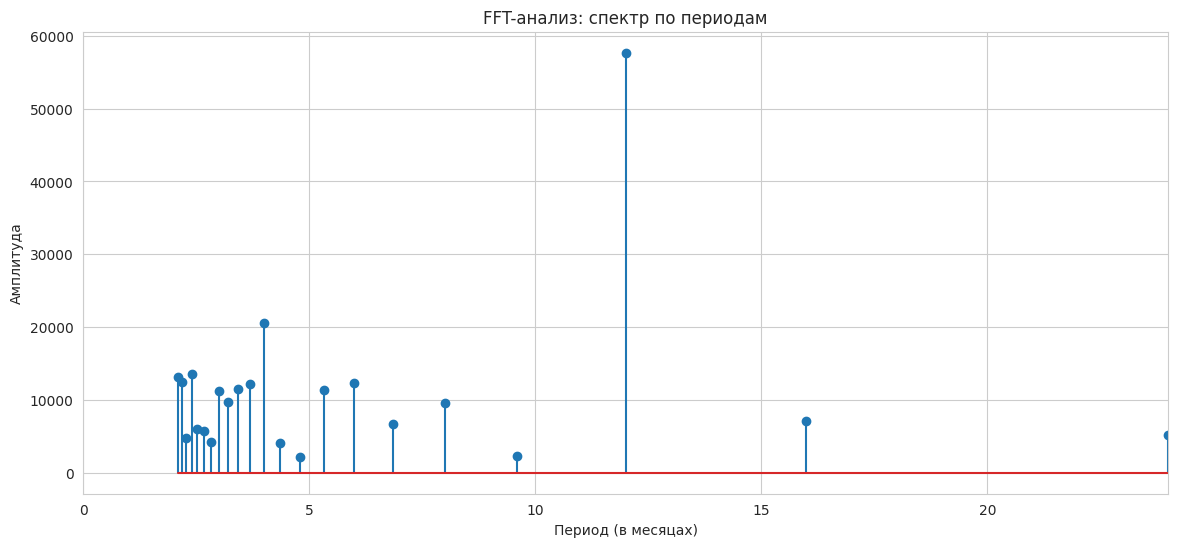

In [22]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.stem(fft_df["period_months"], fft_df["amplitude"])
ax.set_title("FFT-анализ: спектр по периодам")
ax.set_xlabel("Период (в месяцах)")
ax.set_ylabel("Амплитуда")
ax.set_xlim(0, 24)
plt.show()

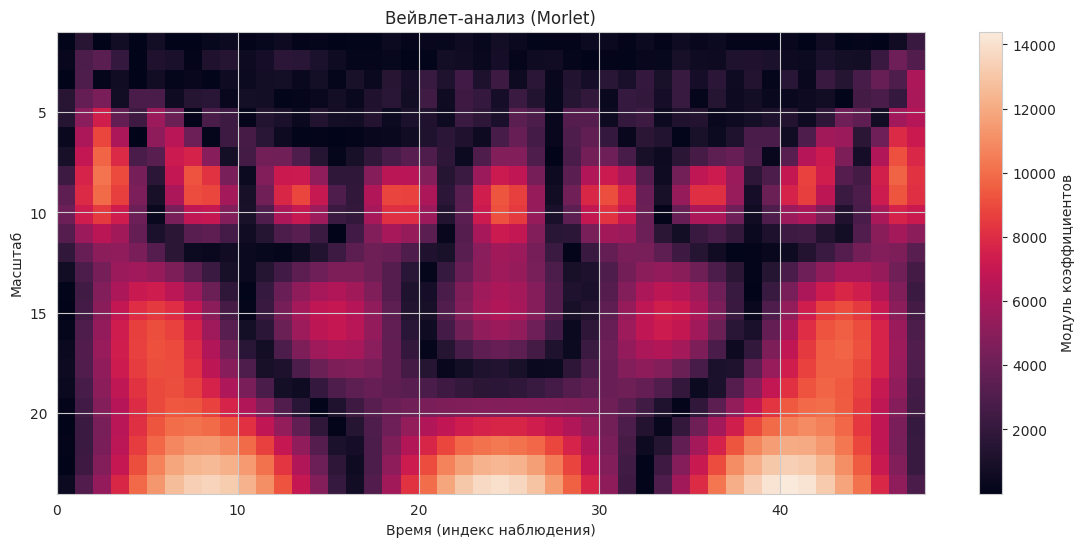

In [23]:
scales = np.arange(1, 25)
coefficients, frequencies = pywt.cwt(ts.values, scales, "morl")

plt.figure(figsize=(14, 6))
plt.imshow(
    np.abs(coefficients),
    extent=[0, len(ts), scales.max(), scales.min()],
    aspect="auto"
)
plt.colorbar(label="Модуль коэффициентов")
plt.title("Вейвлет-анализ (Morlet)")
plt.xlabel("Время (индекс наблюдения)")
plt.ylabel("Масштаб")
plt.show()

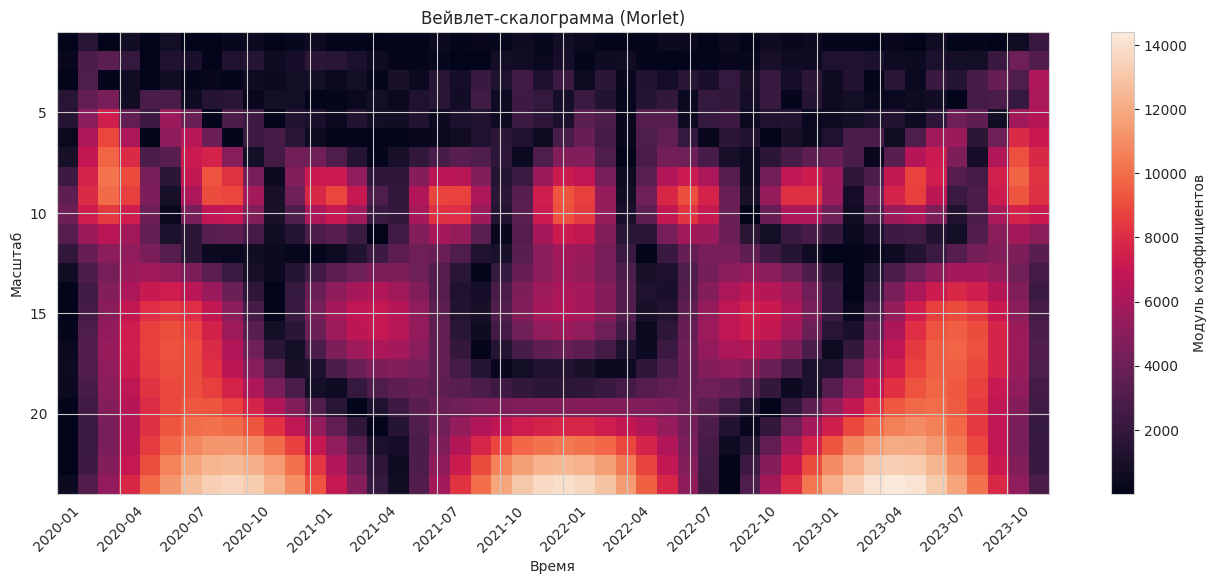

In [24]:
time_labels = ts.index.strftime("%Y-%m")

plt.figure(figsize=(16, 6))
plt.imshow(
    np.abs(coefficients),
    extent=[0, len(ts) - 1, scales.max(), scales.min()],
    aspect="auto"
)
plt.colorbar(label="Модуль коэффициентов")
plt.title("Вейвлет-скалограмма (Morlet)")
plt.xlabel("Время")
plt.ylabel("Масштаб")

tick_positions = np.arange(0, len(ts), 3)
tick_labels = [time_labels[i] for i in tick_positions]
plt.xticks(tick_positions, tick_labels, rotation=45)

plt.show()

In [26]:
methods_comparison = pd.DataFrame({
    "Метод": [
        "Аддитивная декомпозиция",
        "Мультипликативная декомпозиция",
        "STL-декомпозиция",
        "FFT-анализ",
        "Вейвлет-анализ"
    ],
    "Что показывает": [
        "Тренд, сезонность и остаток при суммарной модели",
        "Тренд, сезонность и остаток при пропорциональной модели",
        "Гибкое разложение на тренд, сезонность и остаток",
        "Доминирующие циклы и периодичности",
        "Изменение частотных компонентов во времени"
    ],
    "Преимущества": [
        "Простая интерпретация",
        "Хороша при масштабируемой сезонности",
        "Устойчива к шуму, гибче классической схемы",
        "Хорошо выявляет скрытые циклы",
        "Подходит для нестационарных процессов"
    ],
    "Ограничения": [
        "Менее гибкая при сложной структуре ряда",
        "Требует положительных значений и не всегда устойчива",
        "Сложнее интерпретировать, чем классическую модель",
        "Не показывает локализацию во времени",
        "Сложнее интерпретация результатов"
    ]
})

display(methods_comparison)

,Метод,Что показывает,Преимущества,Ограничения
0,Аддитивная декомпозиция,"Тренд, сезонность и остаток при суммарной модели",Простая интерпретация,Менее гибкая при сложной структуре ряда
1,Мультипликативная декомпозиция,"Тренд, сезонность и остаток при пропорциональн...",Хороша при масштабируемой сезонности,Требует положительных значений и не всегда уст...
2,STL-декомпозиция,"Гибкое разложение на тренд, сезонность и остаток","Устойчива к шуму, гибче классической схемы","Сложнее интерпретировать, чем классическую модель"
3,FFT-анализ,Доминирующие циклы и периодичности,Хорошо выявляет скрытые циклы,Не показывает локализацию во времени
4,Вейвлет-анализ,Изменение частотных компонентов во времени,Подходит для нестационарных процессов,Сложнее интерпретация результатов


## 4. Построение прогнозных моделей ARIMA и SARIMAX

На этом этапе строятся прогнозные модели для временного ряда продаж.

Подход:
- выделяется обучающая и тестовая выборка;
- для теста оставляется 12 последних месяцев, чтобы проверить прогноз на полном сезонном цикле;
- строятся несколько моделей ARIMA и SARIMAX;
- в SARIMAX дополнительно используются экзогенные признаки:
  - `Promotion`
  - `HolidayMonth`

Далее модели будут сравнены по качеству прогноза и информационным критериям.

In [27]:
test_size = 12

train_ts = ts.iloc[:-test_size]
test_ts = ts.iloc[-test_size:]

print("Train period:", train_ts.index.min(), "->", train_ts.index.max())
print("Test period:", test_ts.index.min(), "->", test_ts.index.max())
print("Train size:", len(train_ts))
print("Test size:", len(test_ts))

Train period: 2020-01-01 00:00:00 -> 2022-12-01 00:00:00
Test period: 2023-01-01 00:00:00 -> 2023-12-01 00:00:00
Train size: 36
Test size: 12


In [28]:
exog_features = ["Promotion", "HolidayMonth"]

train_exog = df[exog_features].iloc[:-test_size]
test_exog = df[exog_features].iloc[-test_size:]

display(train_exog.head())
display(test_exog.head())

,Promotion,HolidayMonth
Date,,
2020-01-01,0,0
2020-02-01,0,0
2020-03-01,0,0
2020-04-01,1,0
2020-05-01,0,0


,Promotion,HolidayMonth
Date,,
2023-01-01,0,0
2023-02-01,0,0
2023-03-01,0,0
2023-04-01,0,0
2023-05-01,1,0


In [30]:
def fit_and_forecast(model_name, order, seasonal_order=None, use_exog=False):
    """
    Обучает модель ARIMA/SARIMAX и строит прогноз на тестовом горизонте.
    Возвращает словарь с моделью, прогнозом и метриками.
    """
    try:
        if seasonal_order is None and not use_exog:
            # Обычная ARIMA
            model = ARIMA(train_ts, order=order)
            fitted_model = model.fit()
            forecast = fitted_model.forecast(steps=len(test_ts))
        else:
            # SARIMAX (сезонная модель, возможно с exog)
            model = SARIMAX(
                train_ts,
                exog=train_exog if use_exog else None,
                order=order,
                seasonal_order=seasonal_order if seasonal_order is not None else (0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            fitted_model = model.fit(disp=False)
            forecast = fitted_model.forecast(
                steps=len(test_ts),
                exog=test_exog if use_exog else None
            )

        result = {
            "Model": model_name,
            "Order": order,
            "SeasonalOrder": seasonal_order,
            "UseExog": use_exog,
            "MSE": mean_squared_error(test_ts, forecast),
            "R2": r2_score(test_ts, forecast),
            "AIC": fitted_model.aic,
            "BIC": fitted_model.bic,
            "Forecast": forecast,
            "FittedModel": fitted_model,
            "Error": None
        }

    except Exception as e:
        result = {
            "Model": model_name,
            "Order": order,
            "SeasonalOrder": seasonal_order,
            "UseExog": use_exog,
            "MSE": np.nan,
            "R2": np.nan,
            "AIC": np.nan,
            "BIC": np.nan,
            "Forecast": None,
            "FittedModel": None,
            "Error": str(e)
        }

    return result

In [31]:
candidate_models = [
    {
        "model_name": "ARIMA(1,1,1)",
        "order": (1, 1, 1),
        "seasonal_order": None,
        "use_exog": False,
    },
    {
        "model_name": "ARIMA(2,1,2)",
        "order": (2, 1, 2),
        "seasonal_order": None,
        "use_exog": False,
    },
    {
        "model_name": "SARIMAX(1,1,1)x(1,1,1,12)",
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 1, 12),
        "use_exog": False,
    },
    {
        "model_name": "SARIMAX_exog(1,1,1)x(1,1,1,12)",
        "order": (1, 1, 1),
        "seasonal_order": (1, 1, 1, 12),
        "use_exog": True,
    },
    {
        "model_name": "SARIMAX_exog(0,1,1)x(1,1,1,12)",
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 1, 12),
        "use_exog": True,
    },
]

results = []

for config in candidate_models:
    result = fit_and_forecast(
        model_name=config["model_name"],
        order=config["order"],
        seasonal_order=config["seasonal_order"],
        use_exog=config["use_exog"],
    )
    results.append(result)

print("Количество обученных моделей:", len(results))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_date

Количество обученных моделей: 5


In [32]:
comparison_results = pd.DataFrame([
    {
        "Model": item["Model"],
        "Order": str(item["Order"]),
        "SeasonalOrder": str(item["SeasonalOrder"]),
        "UseExog": item["UseExog"],
        "MSE": item["MSE"],
        "R2": item["R2"],
        "AIC": item["AIC"],
        "BIC": item["BIC"],
        "Error": item["Error"],
    }
    for item in results
])

comparison_results = comparison_results.sort_values("MSE", ascending=True).reset_index(drop=True)

display(comparison_results)

,Model,Order,SeasonalOrder,UseExog,MSE,R2,AIC,BIC,Error
0,"SARIMAX_exog(1,1,1)x(1,1,1,12)","(1, 1, 1)","(1, 1, 1, 12)",True,6.047461e+05,0.869240,152.670382,154.050954,None
1,"SARIMAX_exog(0,1,1)x(1,1,1,12)","(0, 1, 1)","(1, 1, 1, 12)",True,6.267967e+05,0.864472,151.493270,152.676617,None
2,"SARIMAX(1,1,1)x(1,1,1,12)","(1, 1, 1)","(1, 1, 1, 12)",False,1.931951e+06,0.582268,157.805816,158.791939,None
3,"ARIMA(1,1,1)","(1, 1, 1)",None,False,1.256260e+07,-1.716324,643.802918,648.468962,None
4,"ARIMA(2,1,2)","(2, 1, 2)",None,False,1.379739e+07,-1.983313,642.787277,650.564017,None


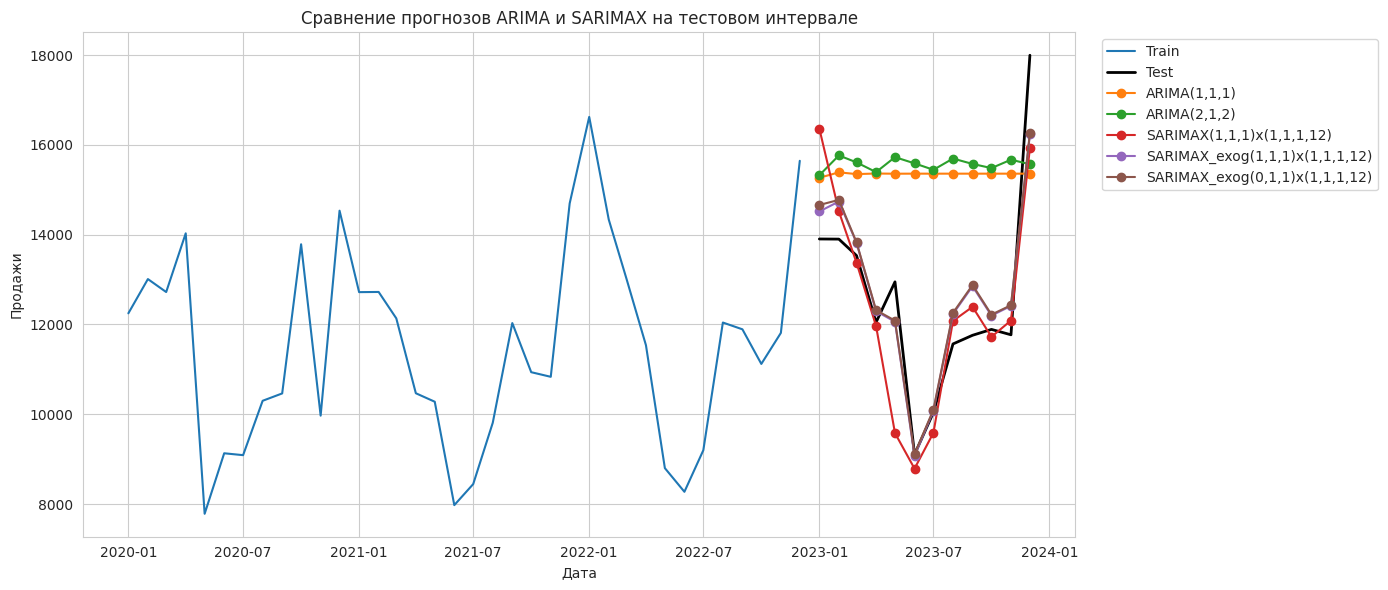

In [33]:
plt.figure(figsize=(14, 6))

plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(test_ts.index, test_ts, label="Test", color="black", linewidth=2)

for item in results:
    if item["Forecast"] is not None:
        plt.plot(
            test_ts.index,
            item["Forecast"],
            marker="o",
            label=item["Model"]
        )

plt.title("Сравнение прогнозов ARIMA и SARIMAX на тестовом интервале")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [34]:
valid_results = comparison_results.dropna(subset=["MSE"]).copy()

best_by_mse = valid_results.sort_values("MSE", ascending=True).iloc[0]
best_by_aic = valid_results.sort_values("AIC", ascending=True).iloc[0]
best_by_bic = valid_results.sort_values("BIC", ascending=True).iloc[0]

print("Лучшая модель по MSE:", best_by_mse["Model"])
print("Лучшая модель по AIC:", best_by_aic["Model"])
print("Лучшая модель по BIC:", best_by_bic["Model"])

Лучшая модель по MSE: SARIMAX_exog(1,1,1)x(1,1,1,12)
Лучшая модель по AIC: SARIMAX_exog(0,1,1)x(1,1,1,12)
Лучшая модель по BIC: SARIMAX_exog(0,1,1)x(1,1,1,12)


In [35]:
best_model_name = best_by_mse["Model"]

best_result = None
for item in results:
    if item["Model"] == best_model_name:
        best_result = item
        break

best_model = best_result["FittedModel"]
best_forecast = best_result["Forecast"]

print("Выбранная модель для дальнейшего анализа остатков:", best_model_name)

Выбранная модель для дальнейшего анализа остатков: SARIMAX_exog(1,1,1)x(1,1,1,12)


Аналитический вывод по этапу построения моделей:

1. Для проверки качества прогноза временной ряд был разделен на обучающую и тестовую выборки.
   В тестовую выборку включены последние 12 месяцев, что позволяет оценить прогноз на полном сезонном цикле.

2. Были построены как несезонные модели ARIMA, так и сезонные модели SARIMAX.
   Это соответствует характеру ряда, так как на предыдущих этапах была выявлена выраженная годовая сезонность.

3. Для моделей SARIMAX дополнительно использованы экзогенные признаки Promotion и HolidayMonth,
   поскольку EDA показал, что они могут оказывать влияние на объем продаж.

4. После обучения моделей сформирована таблица сравнения, содержащая:
   - MSE,
   - R²,
   - AIC,
   - BIC.

5. По графикам прогноза и табличным метрикам можно сделать предварительный вывод о том,
   какая модель лучше описывает тестовый участок ряда.

6. На следующем этапе будет выполнен анализ остатков лучшей модели:
   проверка нормальности, автокоррелированности и гомоскедастичности.

## 5. Оценка качества моделей и анализ остатков

На этом этапе выполняется:

- детальный анализ лучшей модели;
- построение графиков прогноза и ошибок;
- анализ остатков модели;
- проверка остатков на:
  - нормальность,
  - автокоррелированность,
  - гомоскедастичность;
- формирование итогового вывода о предпочтительной модели.

In [36]:
import statsmodels.api as sm

residuals = pd.Series(best_model.resid).dropna()

forecast_errors = test_ts - best_forecast

print("Лучшая модель:", best_model_name)
print("Количество остатков:", len(residuals))
print("Количество ошибок прогноза:", len(forecast_errors))

display(pd.DataFrame({
    "Actual": test_ts,
    "Forecast": best_forecast,
    "ForecastError": forecast_errors
}))

Лучшая модель: SARIMAX_exog(1,1,1)x(1,1,1,12)
Количество остатков: 36
Количество ошибок прогноза: 12


,Actual,Forecast,ForecastError
2023-01-01,13904,14516.455152,-612.455152
2023-02-01,13901,14738.117897,-837.117897
2023-03-01,13534,13818.425049,-284.425049
2023-04-01,12048,12295.444989,-247.444989
2023-05-01,12949,12061.172484,887.827516
2023-06-01,9104,9074.741909,29.258091
2023-07-01,10042,10079.548895,-37.548895
2023-08-01,11566,12234.920404,-668.920404
2023-09-01,11759,12851.952783,-1092.952783
2023-10-01,11890,12197.470328,-307.470328


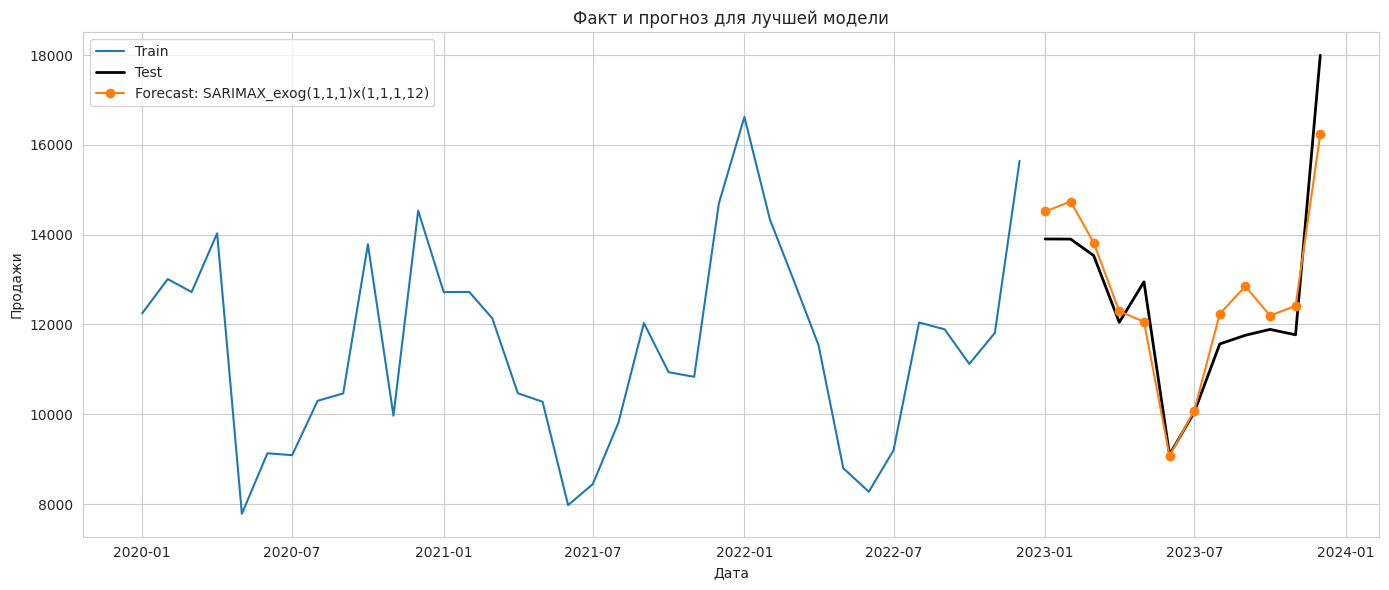

In [37]:
plt.figure(figsize=(14, 6))

plt.plot(train_ts.index, train_ts, label="Train")
plt.plot(test_ts.index, test_ts, label="Test", color="black", linewidth=2)
plt.plot(test_ts.index, best_forecast, marker="o", label=f"Forecast: {best_model_name}")

plt.title("Факт и прогноз для лучшей модели")
plt.xlabel("Дата")
plt.ylabel("Продажи")
plt.legend()
plt.tight_layout()
plt.show()

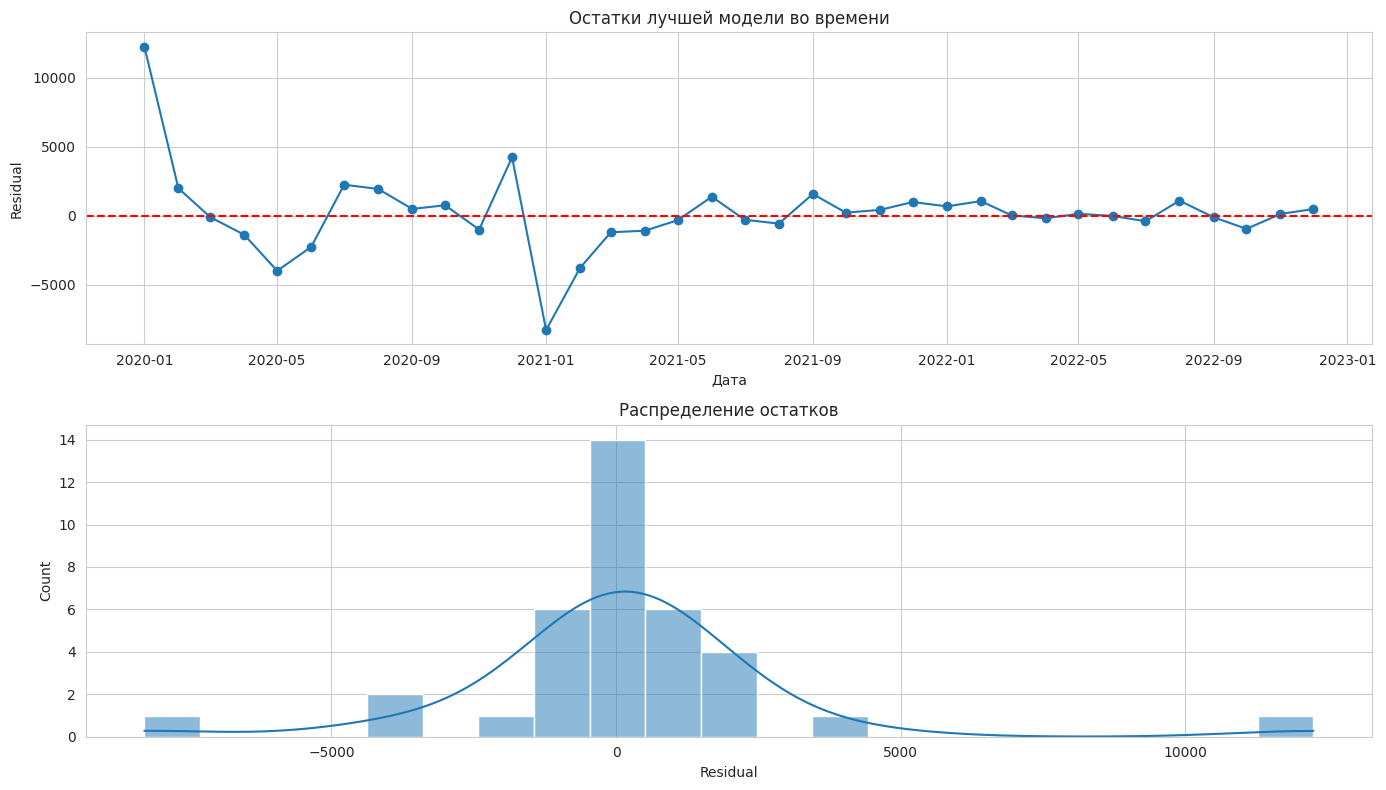

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(residuals.index, residuals.values, marker="o")
axes[0].axhline(0, color="red", linestyle="--")
axes[0].set_title("Остатки лучшей модели во времени")
axes[0].set_xlabel("Дата")
axes[0].set_ylabel("Residual")

sns.histplot(residuals, kde=True, ax=axes[1])
axes[1].set_title("Распределение остатков")
axes[1].set_xlabel("Residual")

plt.tight_layout()
plt.show()

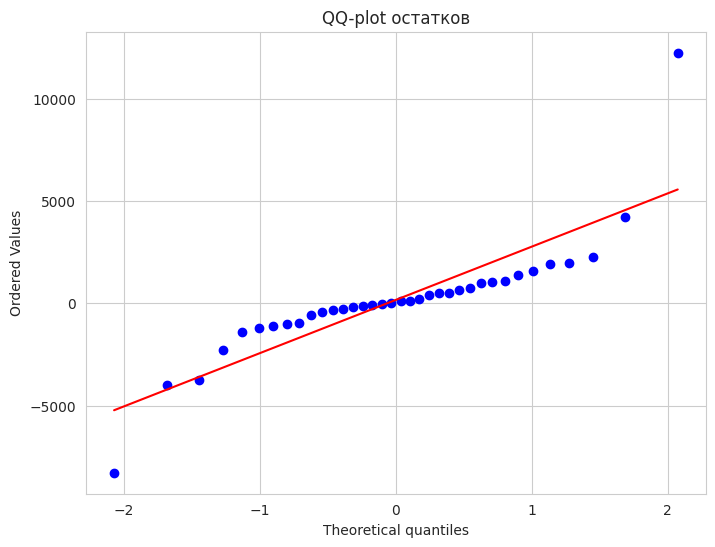

In [39]:
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("QQ-plot остатков")
plt.show()

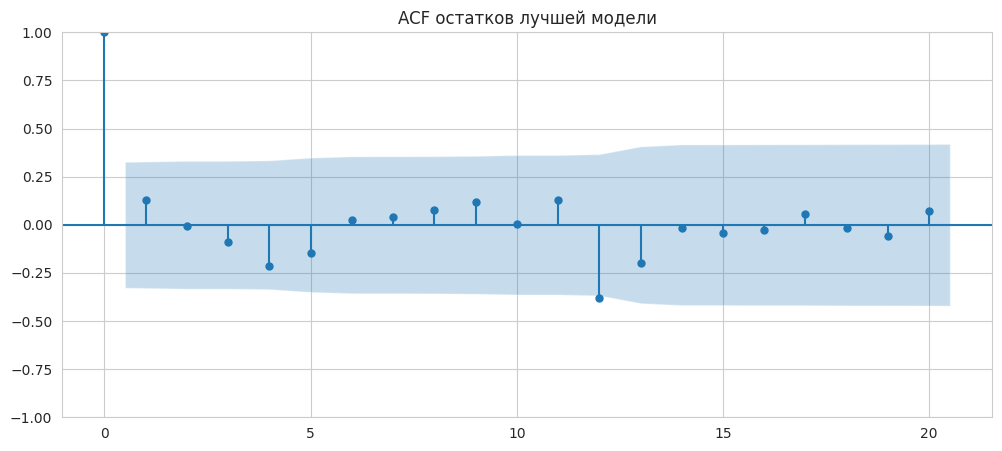

In [40]:
fig, ax = plt.subplots(figsize=(12, 5))
plot_acf(residuals, lags=min(20, len(residuals) - 1), ax=ax)
ax.set_title("ACF остатков лучшей модели")
plt.show()

In [41]:
jb_stat, jb_pvalue, skew_value, kurtosis_value = jarque_bera(residuals)

lb_df = acorr_ljungbox(residuals, lags=[6, 12], return_df=True)

fitted_values = pd.Series(best_model.fittedvalues)
fitted_values = fitted_values.loc[residuals.index]

bp_X = sm.add_constant(fitted_values.values)
bp_lm_stat, bp_lm_pvalue, bp_f_stat, bp_f_pvalue = het_breuschpagan(residuals.values, bp_X)

diagnostics_table = pd.DataFrame({
    "Test": [
        "Jarque-Bera (normality)",
        "Ljung-Box lag=6 (autocorrelation)",
        "Ljung-Box lag=12 (autocorrelation)",
        "Breusch-Pagan LM (heteroskedasticity)",
        "Breusch-Pagan F (heteroskedasticity)",
    ],
    "Statistic": [
        jb_stat,
        lb_df.iloc[0]["lb_stat"],
        lb_df.iloc[1]["lb_stat"],
        bp_lm_stat,
        bp_f_stat,
    ],
    "p-value": [
        jb_pvalue,
        lb_df.iloc[0]["lb_pvalue"],
        lb_df.iloc[1]["lb_pvalue"],
        bp_lm_pvalue,
        bp_f_pvalue,
    ]
})

display(diagnostics_table)

,Test,Statistic,p-value
0,Jarque-Bera (normality),103.715938,3.008641e-23
1,Ljung-Box lag=6 (autocorrelation),3.933849,6.856281e-01
2,Ljung-Box lag=12 (autocorrelation),14.214593,2.872152e-01
3,Breusch-Pagan LM (heteroskedasticity),3.482144,6.203432e-02
4,Breusch-Pagan F (heteroskedasticity),3.640858,6.485150e-02


In [42]:
def interpret_pvalue(test_name, pvalue, null_hypothesis):
    if pvalue >= 0.05:
        return f"{test_name}: нет оснований отвергнуть H0 ({null_hypothesis})."
    return f"{test_name}: H0 отвергается ({null_hypothesis} не выполняется)."

print(interpret_pvalue("Jarque-Bera", jb_pvalue, "остатки распределены нормально"))
print(interpret_pvalue("Ljung-Box lag=6", lb_df.iloc[0]["lb_pvalue"], "остатки не автокоррелированы"))
print(interpret_pvalue("Ljung-Box lag=12", lb_df.iloc[1]["lb_pvalue"], "остатки не автокоррелированы"))
print(interpret_pvalue("Breusch-Pagan LM", bp_lm_pvalue, "остатки гомоскедастичны"))
print(interpret_pvalue("Breusch-Pagan F", bp_f_pvalue, "остатки гомоскедастичны"))

Jarque-Bera: H0 отвергается (остатки распределены нормально не выполняется).
Ljung-Box lag=6: нет оснований отвергнуть H0 (остатки не автокоррелированы).
Ljung-Box lag=12: нет оснований отвергнуть H0 (остатки не автокоррелированы).
Breusch-Pagan LM: нет оснований отвергнуть H0 (остатки гомоскедастичны).
Breusch-Pagan F: нет оснований отвергнуть H0 (остатки гомоскедастичны).


In [43]:
best_forecast_df = pd.DataFrame({
    "Actual": test_ts,
    "Forecast": best_forecast,
    "Error": test_ts - best_forecast,
    "AbsoluteError": np.abs(test_ts - best_forecast),
    "SquaredError": (test_ts - best_forecast) ** 2,
})

display(best_forecast_df)
print("MSE лучшей модели:", mean_squared_error(test_ts, best_forecast))
print("R² лучшей модели:", r2_score(test_ts, best_forecast))

,Actual,Forecast,Error,AbsoluteError,SquaredError
2023-01-01,13904,14516.455152,-612.455152,612.455152,3.751013e+05
2023-02-01,13901,14738.117897,-837.117897,837.117897,7.007664e+05
2023-03-01,13534,13818.425049,-284.425049,284.425049,8.089761e+04
2023-04-01,12048,12295.444989,-247.444989,247.444989,6.122902e+04
2023-05-01,12949,12061.172484,887.827516,887.827516,7.882377e+05
2023-06-01,9104,9074.741909,29.258091,29.258091,8.560359e+02
2023-07-01,10042,10079.548895,-37.548895,37.548895,1.409920e+03
2023-08-01,11566,12234.920404,-668.920404,668.920404,4.474545e+05
2023-09-01,11759,12851.952783,-1092.952783,1092.952783,1.194546e+06
2023-10-01,11890,12197.470328,-307.470328,307.470328,9.453800e+04


MSE лучшей модели: 604746.1035249451
R² лучшей модели: 0.8692399553954198


In [44]:
final_comparison = comparison_results.copy()

final_comparison["MSE_rank"] = final_comparison["MSE"].rank(method="min")
final_comparison["AIC_rank"] = final_comparison["AIC"].rank(method="min")
final_comparison["BIC_rank"] = final_comparison["BIC"].rank(method="min")

display(final_comparison.sort_values(["MSE_rank", "AIC_rank", "BIC_rank"]))

,Model,Order,SeasonalOrder,UseExog,MSE,R2,AIC,BIC,Error,MSE_rank,AIC_rank,BIC_rank
0,"SARIMAX_exog(1,1,1)x(1,1,1,12)","(1, 1, 1)","(1, 1, 1, 12)",True,6.047461e+05,0.869240,152.670382,154.050954,None,1.0,2.0,2.0
1,"SARIMAX_exog(0,1,1)x(1,1,1,12)","(0, 1, 1)","(1, 1, 1, 12)",True,6.267967e+05,0.864472,151.493270,152.676617,None,2.0,1.0,1.0
2,"SARIMAX(1,1,1)x(1,1,1,12)","(1, 1, 1)","(1, 1, 1, 12)",False,1.931951e+06,0.582268,157.805816,158.791939,None,3.0,3.0,3.0
3,"ARIMA(1,1,1)","(1, 1, 1)",None,False,1.256260e+07,-1.716324,643.802918,648.468962,None,4.0,5.0,4.0
4,"ARIMA(2,1,2)","(2, 1, 2)",None,False,1.379739e+07,-1.983313,642.787277,650.564017,None,5.0,4.0,5.0


Итоговый вывод по моделям:

1. По результатам сравнения моделей была выбрана модель: {best_model_name}.

2. Выбор выполнялся на основе качества прогноза на тестовой выборке,
   а также с учетом информационных критериев AIC и BIC.

3. Если модель показывает низкий MSE, высокий R² и приемлемые результаты
   диагностики остатков, ее можно считать предпочтительной для данного ряда.

4. Если при этом в остатках сохраняется автокорреляция или наблюдаются признаки
   ненормальности/гетероскедастичности, это означает, что модель хорошо прогнозирует,
   но не полностью описывает внутреннюю структуру ряда.

5. Для ряда розничных продаж сезонные модели SARIMAX обычно оказываются предпочтительнее
   обычных ARIMA, поскольку способны учитывать годовую сезонность и влияние внешних факторов
   (например, Promotion и HolidayMonth).

6. Следовательно, предпочтительной считается та модель, которая обеспечивает наилучший баланс между:
   - качеством прогноза,
   - устойчивостью,
   - интерпретируемостью,
   - корректностью остатков.

Финальный аналитический вывод по лабораторной работе:

1. В ходе работы был исследован временной ряд розничных продаж.
   Выполнен разведочный анализ данных, который показал наличие выраженной сезонности
   и возможного влияния внешних факторов.

2. Для изучения структуры ряда были применены несколько методов декомпозиции:
   классическая аддитивная, мультипликативная, STL-декомпозиция, FFT-анализ и вейвлет-анализ.
   Это позволило выявить тренд, сезонную составляющую и особенности колебаний ряда.

3. На основе результатов анализа были построены модели ARIMA и SARIMAX.
   Для SARIMAX дополнительно использованы экзогенные признаки Promotion и HolidayMonth.

4. Качество моделей было оценено по метрикам MSE и R²,
   а также по информационным критериям AIC и BIC.

5. Для лучшей модели выполнен анализ остатков, включающий проверку:
   - нормальности,
   - автокоррелированности,
   - гомоскедастичности.

6. По итогам сравнения можно сделать вывод, что сезонная модель является более подходящей
   для анализа и прогнозирования данного временного ряда, чем несезонная,
   поскольку она лучше учитывает структуру данных и повторяющиеся сезонные колебания.

7. Поставленная цель работы достигнута:
   временной ряд исследован, модели построены, их качество оценено,
   предпочтительная модель выбрана и интерпретирована.

## Заключение

В лабораторной работе был выполнен полный цикл анализа временного ряда розничных продаж: от предварительного исследования данных и декомпозиции до построения прогнозных моделей и диагностики их качества.

Полученные результаты показывают, что для временных рядов с выраженной сезонностью наиболее информативными являются сезонные модели, особенно при наличии дополнительных внешних факторов.

Таким образом, методы временных рядов позволяют не только строить прогноз, но и глубже понимать внутреннюю структуру исследуемого процесса.